In [18]:
import torch 
import torch.nn as nn 
from torch.nn import functional as F 
import sys 
sys.path.append('..')
from train import TrainModel
from custom_dataset.adatasets import get_dataloader
from einops import rearrange
from matplotlib import pyplot as plt 

In [2]:
_, test_loader = get_dataloader()

In [3]:

model = TrainModel.load_from_checkpoint("/home/kathy/projects/project_guo/test/logs/train_a/version_2/checkpoints/epoch=67-step=30532.ckpt")

In [4]:
model.device 

device(type='cuda', index=1)

In [5]:
X, y = next(iter(test_loader))

In [6]:
X.shape, y.shape 

(torch.Size([1, 24, 1, 128, 128]), torch.Size([1, 24, 1, 128, 128]))

In [7]:
X = X.to(model.device)
y = y.to(model.device)

In [10]:
X =  rearrange(X, "b n c h w -> (b n) c h w")
y =  rearrange(y, "b n c h w -> (b n) c h w")

In [11]:
output = model(X)

/home/kathy/anaconda3/envs/hkx/lib/python3.8/site-packages/torch/nn/functional.py:3722: UserWarning: nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.
  warnings.warn("nn.functional.upsample is deprecated. Use nn.functional.interpolate instead.")


In [12]:
output.shape 

torch.Size([24, 5, 128, 128])

In [20]:
y.shape 

torch.Size([24, 1, 128, 128])

In [22]:
pred_zones = torch.zeros((6 * 128, 4* 128))
pred_zones.shape 

torch.Size([768, 512])

In [23]:
true_zones = torch.zeros((6 * 128, 4* 128))

In [28]:
for i in range(6):
    for j in range(4):
        pred_temp = output[i * 4 + j, :, :, :].argmax(dim = 0) # 128, 128
        target_temp = y[i * 4 + j, 0, :, :] # 128, 128
        pred_zones[i * 128 : (i + 1) * 128, j * 128 : (j + 1) * 128] = pred_temp
        true_zones[i * 128 : (i + 1) * 128, j * 128 : (j + 1) * 128] = target_temp

In [29]:
pred_img = pred_zones.detach().cpu().numpy()
true_img = true_zones.detach().cpu().numpy()

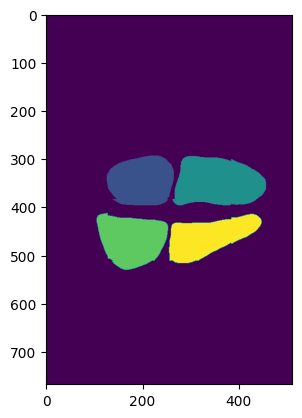

In [30]:
plt.imshow(pred_img)

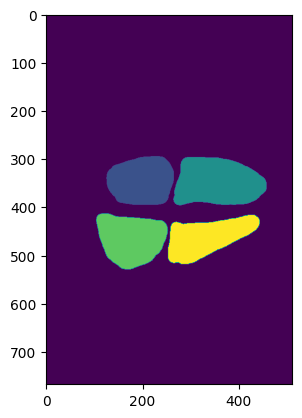

In [31]:
plt.imshow(true_img)

In [32]:
output.shape 

torch.Size([24, 5, 128, 128])

In [33]:
y.shape 

torch.Size([24, 1, 128, 128])